In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import torch
import copy
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.trainer import SimpleTrainer, FisherTrainer, IntervalTrainer
from src.data_utils import (
    get_mnist_tasks,
    _extract_targets,
    get_context_sets,
    create_holdout_set,
)
from src.utils.general import InContextHead
from src import models
from src.regulariser import UnbiasRegulariser, L2Regulariser, MultiRegulariser

from configs import MNIST_FISHER_CONFIG as CONFIG

In [4]:
SEED = 0
train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=SEED)

context_sets = get_context_sets(test_tasks)
head = InContextHead(context_sets, 10, device="cuda")
head.set_context(0)
model = models.get_mnist_model(head=head, device="cuda", seed=SEED)

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)


Tasks: [[7, 8], [0, 9], [1, 2], [3, 6], [4, 5]]


In [ ]:
interval_trainer = IntervalTrainer(
    model,
    checkpoint=CONFIG["checkpoint"],
    n_iters=CONFIG["n_iters"],
    min_acc_limit=CONFIG["min_acc_limit"],
    min_acc_increment=CONFIG["min_acc_increment"],
    primal_learning_rate=CONFIG["primal_learning_rate"],
    dual_learning_rate=CONFIG["dual_learning_rate"],
    projection_strategy=CONFIG["projection_strategy"],
    n_certificate_samples=CONFIG["n_certificate_samples"],
    penalty_coefficient=CONFIG["penalty_coefficient"],
    paradigm="TIL",
    seed=SEED,
)

interval_trainer.train(
    train_tasks[0],
    val_tasks[0],
    batch_size=CONFIG["batch_size"],
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    context_id=0,
)

interval_trainer.compute_rashomon_set(test_tasks[0], context_id=0)

interval_trainer.train(
    train_tasks[1],
    val_tasks[1],
    batch_size=CONFIG["batch_size"],
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    context_id=1,
)
interval_trainer.test(test_tasks, context_list=list(range(len(test_tasks))))

In [ ]:
fisher_trainer = FisherTrainer(
    model,
    checkpoint=CONFIG["checkpoint"],
    n_iters=CONFIG["n_iters"],
    min_acc_limit=CONFIG["min_acc_limit"],
    min_acc_increment=CONFIG["min_acc_increment"],
    primal_learning_rate=CONFIG["primal_learning_rate"],
    dual_learning_rate=CONFIG["dual_learning_rate"],
    projection_strategy=CONFIG["projection_strategy"],
    n_certificate_samples=CONFIG["n_certificate_samples"],
    penalty_coefficient=CONFIG["penalty_coefficient"],
    paradigm="TIL",
    seed=SEED,
)

fisher_trainer.train(
    train_tasks[0],
    val_tasks[0],
    batch_size=CONFIG["batch_size"],
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    context_id=0,
)

fisher_trainer.compute_rashomon_set(
    test_tasks[0], test_tasks[1], context_id=0, prune_prop=0
)

fisher_trainer.train(
    train_tasks[1],
    val_tasks[1],
    batch_size=CONFIG["batch_size"],
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    context_id=1,
)
fisher_trainer.test(test_tasks, context_list=list(range(len(test_tasks))))

### Task Incremental Learning

In [ ]:
SEED = 0
train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=SEED)

context_sets = get_context_sets(test_tasks)
head = InContextHead(context_sets, 10, device="cuda")
head.set_context(0)
model = models.get_mnist_model(head=head, device="cuda", seed=SEED)

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

In [ ]:
fisher_trainer = FisherTrainer(
    model,
    checkpoint=CONFIG["checkpoint"],
    n_iters=CONFIG["n_iters"],
    min_acc_limit=CONFIG["min_acc_limit"],
    min_acc_increment=CONFIG["min_acc_increment"],
    primal_learning_rate=CONFIG["primal_learning_rate"],
    dual_learning_rate=CONFIG["dual_learning_rate"],
    projection_strategy=CONFIG["projection_strategy"],
    n_certificate_samples=CONFIG["n_certificate_samples"],
    penalty_coefficient=CONFIG["penalty_coefficient"],
    paradigm="TIL",
    seed=SEED,
)

for i, (train, val, test) in enumerate(zip(train_tasks, val_tasks, test_tasks)):
    fisher_trainer.train(
        train,
        val,
        batch_size=CONFIG["batch_size"],
        epochs=CONFIG["epochs"],
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
        context_id=i,
    )
    fisher_trainer.test(test_tasks, context_list=list(range(len(test_tasks))))

    if i < len(test_tasks) - 1:
        fisher_trainer.compute_rashomon_set(
            test,
            test_tasks[i + 1],
            context_id=i,
            prune_prop=CONFIG["prune_prop"],
            fisher_batch_size=CONFIG["fisher_batch_size"],
            fisher_epochs=CONFIG["fisher_epochs"],
        )

### Domain Incremental Learning

In [4]:
SEED = 0
train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=SEED)

model = models.get_mnist_model(device="cuda", output_dim=2, seed=SEED)

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[7, 8], [0, 9], [1, 2], [3, 6], [4, 5]]


In [5]:
def domain_map_fn(labels: torch.Tensor) -> torch.Tensor:
    """Map the global label to the in context label."""
    return labels % 2

In [7]:
fisher_trainer = FisherTrainer(
    model,
    checkpoint=CONFIG["checkpoint"],
    n_iters=CONFIG["n_iters"],
    min_acc_limit=CONFIG["min_acc_limit"],
    min_acc_increment=CONFIG["min_acc_increment"],
    primal_learning_rate=CONFIG["primal_learning_rate"],
    dual_learning_rate=CONFIG["dual_learning_rate"],
    projection_strategy=CONFIG["projection_strategy"],
    n_certificate_samples=CONFIG["n_certificate_samples"],
    penalty_coefficient=CONFIG["penalty_coefficient"],
    paradigm="DIL",
    domain_map_fn=domain_map_fn,
    seed=SEED,
)

for i, (train, val, test) in enumerate(zip(train_tasks, val_tasks, test_tasks)):
    fisher_trainer.train(
        train,
        val,
        batch_size=CONFIG["batch_size"],
        epochs=CONFIG["epochs"],
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )
    fisher_trainer.test(test_tasks)

    if i < len(test_tasks) - 1:
        fisher_trainer.compute_rashomon_set(
            test,
            test_tasks[i + 1],
            prune_prop=CONFIG["prune_prop"],
            fisher_batch_size=CONFIG["fisher_batch_size"],
            fisher_epochs=CONFIG["fisher_epochs"],
        )

Training Epochs: 100%|█████████████████████████| 5/5 [00:05<00:00,  1.10s/it, val_loss=0.0110, val_acc=0.9967, proj=None]


Test Results: [(0.0235, 0.9915), (0.5784, 0.8381), (1.2203, 0.5708), (3.1147, 0.4365), (5.4571, 0.1852)]
To keep top 20%, found global Fisher threshold: 0.5763
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1250 (Positive = violated)
Number of model parameters: 1563
Computing Rashomon set with min acc limit: 0.87
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.99,  Min acc soft=0.99


100%|███████████████████████████████████████| 200/200 [00:08<00:00, 23.71it/s, size=20.32, obj=0.013, min_soft_acc=1.000]


Final bbox:  Obj=0.01,  Size=20.32,  Min acc hard=0.86,  Min acc soft=0.86
Computing final certificates over 400 samples
Checkpointed every 20 iterations for a total of 10 checkpoints
Checkpoints sizes: ['2.96', '9.93', '14.39', '17.52', '18.03', '18.71', '19.35', '19.71', '20.20', '20.32']
Checkpoint certificates: ['0.93', '0.85', '0.87', '0.86', '0.86', '0.85', '0.86', '0.87', '0.86', '0.86']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|████████████████████████████| 5/5 [00:10<00:00,  2.11s/it, val_loss=0.2743, val_acc=0.9280, proj=8]


...

Test Results: [(0.0351, 0.9855), (0.2674, 0.9271), (1.3399, 0.5778), (3.5894, 0.4842), (7.2028, 0.1153)]
To keep top 20%, found global Fisher threshold: 2.6909
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.0692 (Positive = violated)
Computing Rashomon set within outer box of size: 0.27


Training Epochs: 100%|████████████████████████████| 5/5 [00:06<00:00,  1.25s/it, val_loss=3.3259, val_acc=0.5185, proj=0]


Test Results: [(0.0362, 0.984), (0.2673, 0.9251), (1.4002, 0.5671), (3.5798, 0.4929), (7.2106, 0.1185)]
To keep top 20%, found global Fisher threshold: 3.9745
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1062 (Positive = violated)
Computing Rashomon set within outer box of size: 0.27


Training Epochs: 100%|████████████████████████████| 5/5 [00:05<00:00,  1.17s/it, val_loss=6.5623, val_acc=0.1269, proj=0]


Test Results: [(0.0351, 0.9855), (0.2674, 0.9271), (1.3399, 0.5778), (3.5894, 0.4842), (7.2028, 0.1153)]


### Class Incremental Learning

In [4]:
SEED = 0
train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=SEED)

model = models.get_mnist_model(device="cuda", output_dim=10, seed=SEED)

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[7, 8], [0, 9], [1, 2], [3, 6], [4, 5]]


In [9]:
fisher_trainer = FisherTrainer(
    model,
    checkpoint=CONFIG["checkpoint"],
    n_iters=CONFIG["n_iters"],
    min_acc_limit=CONFIG["min_acc_limit"],
    min_acc_increment=CONFIG["min_acc_increment"],
    primal_learning_rate=CONFIG["primal_learning_rate"],
    dual_learning_rate=CONFIG["dual_learning_rate"],
    projection_strategy=CONFIG["projection_strategy"],
    n_certificate_samples=CONFIG["n_certificate_samples"],
    penalty_coefficient=CONFIG["penalty_coefficient"],
    paradigm="CIL",
    seed=SEED,
)

for i, (train, val, test) in enumerate(zip(train_tasks, val_tasks, test_tasks)):
    fisher_trainer.train(
        train,
        val,
        batch_size=CONFIG["batch_size"],
        epochs=CONFIG["epochs"],
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )
    fisher_trainer.test(test_tasks)

    if i < len(test_tasks) - 1:
        fisher_trainer.compute_rashomon_set(
            test,
            test_tasks[i + 1],
            prune_prop=CONFIG["prune_prop"],
            fisher_batch_size=CONFIG["fisher_batch_size"],
            fisher_epochs=CONFIG["fisher_epochs"],
        )

Training Epochs: 100%|█████████████████████████| 5/5 [00:05<00:00,  1.15s/it, val_loss=0.0141, val_acc=0.9947, proj=None]


Test Results: [(0.0358, 0.9865), (46.3004, 0.0), (39.2716, 0.0), (47.2765, 0.0), (43.7228, 0.0)]
To keep top 20%, found global Fisher threshold: 3.4296
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1251 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.86
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.99,  Min acc soft=0.99


100%|██████████████████████████████████████| 200/200 [00:08<00:00, 24.00it/s, size=112.70, obj=0.018, min_soft_acc=1.000]


Final bbox:  Obj=0.02,  Size=112.70,  Min acc hard=0.93,  Min acc soft=0.92
Computing final certificates over 400 samples
Checkpointed every 20 iterations for a total of 10 checkpoints
Checkpoints sizes: ['4.07', '16.64', '36.25', '55.06', '64.26', '74.36', '85.02', '94.96', '103.73', '112.70']
Checkpoint certificates: ['0.92', '0.94', '0.95', '0.96', '0.94', '0.96', '0.87', '0.88', '0.88', '0.93']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|████████████████████████████| 5/5 [00:10<00:00,  2.13s/it, val_loss=2.9010, val_acc=0.4888, proj=9]


...

Test Results: [(0.0427, 0.9845), (2.691, 0.4615), (39.1152, 0.0), (47.2319, 0.0), (43.4716, 0.0)]
To keep top 20%, found global Fisher threshold: 2.2036
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|███████████████████████████| 5/5 [00:06<00:00,  1.26s/it, val_loss=46.3311, val_acc=0.0000, proj=0]


Test Results: [(0.0427, 0.9845), (2.691, 0.4615), (39.1152, 0.0), (47.2319, 0.0), (43.4716, 0.0)]
To keep top 20%, found global Fisher threshold: 2.6168
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|███████████████████████████| 5/5 [00:05<00:00,  1.17s/it, val_loss=42.5289, val_acc=0.0000, proj=0]


Test Results: [(0.0427, 0.9845), (2.691, 0.4615), (39.1152, 0.0), (47.2319, 0.0), (43.4716, 0.0)]


### Class Incremental Learning + Regulariser

In [5]:
SEED = 1
train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=SEED)

model = models.get_mnist_model(device="cuda", output_dim=10, seed=SEED)

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[0, 7], [5, 8], [4, 9], [3, 6], [1, 2]]


In [6]:
unbias = UnbiasRegulariser(
    lmbd=CONFIG["unbias_lambda"],
    unbias_domain=[
        torch.zeros(1, 1, 28, 28, device="cuda"),
        torch.ones(1, 1, 28, 28, device="cuda"),
    ],
)
l2 = L2Regulariser(lmbd=CONFIG["l2_lambda"])
regulariser = MultiRegulariser([l2, unbias])

In [8]:
fisher_trainer = FisherTrainer(
    model,
    checkpoint=CONFIG["checkpoint"],
    n_iters=CONFIG["n_iters"],
    min_acc_limit=CONFIG["min_acc_limit"],
    min_acc_increment=CONFIG["min_acc_increment"],
    primal_learning_rate=CONFIG["primal_learning_rate"],
    dual_learning_rate=CONFIG["dual_learning_rate"],
    projection_strategy=CONFIG["projection_strategy"],
    n_certificate_samples=CONFIG["n_certificate_samples"],
    penalty_coefficient=CONFIG["penalty_coefficient"],
    paradigm="CIL",
    seed=SEED,
)

for i, (train, val, test) in enumerate(zip(train_tasks, val_tasks, test_tasks)):
    fisher_trainer.train(
        train,
        val,
        batch_size=CONFIG["batch_size"],
        epochs=CONFIG["epochs"],
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
        regulariser=regulariser
    )
    fisher_trainer.test(test_tasks)

    if i < len(test_tasks) - 1:
        fisher_trainer.compute_rashomon_set(
            test,
            test_tasks[i + 1],
            prune_prop=CONFIG["prune_prop"],
            fisher_batch_size=CONFIG["fisher_batch_size"],
            fisher_epochs=CONFIG["fisher_epochs"],
        )

Training Epochs: 100%|█████████████████████████| 5/5 [00:07<00:00,  1.55s/it, val_loss=0.0172, val_acc=0.9960, proj=None]


Test Results: [(0.0154, 0.996), (8.371, 0.0), (8.7936, 0.0), (8.9122, 0.0), (7.1308, 0.0)]
To keep top 20%, found global Fisher threshold: 0.3480
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1177 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.88
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████████████████████████████████| 400/400 [00:17<00:00, 23.53it/s, size=269.28, obj=0.043, min_soft_acc=0.875]


Final bbox:  Obj=0.04,  Size=269.28,  Min acc hard=0.88,  Min acc soft=0.88
Computing final certificates over 400 samples
Checkpointed every 20 iterations for a total of 20 checkpoints
Checkpoints sizes: ['7.56', '20.43', '42.85', '55.49', '72.26', '87.27', '98.84', '114.15', '128.16', '141.01', '153.16', '166.20', '180.07', '193.79', '205.85', '217.83', '230.40', '243.98', '256.07', '269.28']
Checkpoint certificates: ['0.94', '0.98', '0.94', '0.95', '0.87', '0.88', '0.92', '0.87', '0.87', '0.89', '0.88', '0.89', '0.89', '0.89', '0.88', '0.89', '0.90', '0.88', '0.88', '0.88']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|███████████████████████████| 5/5 [00:15<00:00,  3.03s/it, val_loss=0.5489, val_acc=0.8596, proj=19]


...

Test Results: [(0.2038, 0.9671), (0.5486, 0.8526), (9.5226, 0.0), (9.8028, 0.0), (8.1784, 0.0)]
To keep top 20%, found global Fisher threshold: 0.2495
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|████████████████████████████| 5/5 [00:07<00:00,  1.53s/it, val_loss=9.6596, val_acc=0.0000, proj=0]


Test Results: [(0.2038, 0.9671), (0.5486, 0.8526), (9.5226, 0.0), (9.8028, 0.0), (8.1784, 0.0)]
To keep top 20%, found global Fisher threshold: 0.1648
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|████████████████████████████| 5/5 [00:08<00:00,  1.61s/it, val_loss=8.3019, val_acc=0.0000, proj=0]


Test Results: [(0.2038, 0.9671), (0.5486, 0.8526), (9.5226, 0.0), (9.8028, 0.0), (8.1784, 0.0)]


### Experiments

In [5]:
def pretrain(seed: int = 42, use_regulariser: bool = True):
    train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=seed)

    print(
        f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
    )

    unbias = UnbiasRegulariser(
        lmbd=0.01,
        unbias_domain=[
            torch.zeros(1, 1, 28, 28, device="cuda"),
            torch.ones(1, 1, 28, 28, device="cuda"),
        ],
    )
    l2 = L2Regulariser(lmbd=0.01)
    regulariser = MultiRegulariser([l2, unbias])

    model = models.get_mnist_model(device="cuda", seed=seed)

    simple_trainer = SimpleTrainer(model, paradigm="CIL", seed=seed)
    simple_trainer.train(train_tasks[0], val_tasks[0], regulariser=regulariser if use_regulariser else None)
    results = simple_trainer.test(test_tasks)

    return simple_trainer.model, results[0][1] < 0.75

def run_baseline(model: torch.nn.Module, seed: int = 42):
    train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=seed)

    print(
        f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
    )

    unbias = UnbiasRegulariser(
        lmbd=0.01,
        unbias_domain=[
            torch.zeros(1, 1, 28, 28, device="cuda"),
            torch.ones(1, 1, 28, 28, device="cuda"),
        ],
    )
    l2 = L2Regulariser(lmbd=0.01)
    regulariser = MultiRegulariser([l2, unbias])

    interval_trainer = IntervalTrainer(
        model,
        checkpoint=20,
        n_iters=200,
        min_acc_limit=0.8,
        min_acc_increment=0,
        primal_learning_rate=0.5,
        paradigm="CIL",
        seed=seed
    )

    # Test just for verification purposes
    interval_trainer.test(test_tasks)

    interval_trainer.compute_rashomon_set(test_tasks[0])
    interval_trainer.train(train_tasks[1], val_tasks[1], regulariser=regulariser)
    baseline_acc = interval_trainer.test(test_tasks)[1][1]

    return baseline_acc

def run_trial(model: torch.nn.Module, prune_prop: float, lookahead: bool = False, rashomon_iters: int = 200, seed: int = 42):
    train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=seed)

    print(
        f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
    )

    si_trainer = FisherTrainer(
        model,
        checkpoint=100,
        n_iters=300,
        min_acc_limit=0.8,
        min_acc_increment=0,
        primal_learning_rate=0.5,
        paradigm="CIL",
        seed=seed,
    )

    # Test just for verification purposes
    si_trainer.test(test_tasks)
    
    si_trainer.compute_rashomon_set(test_tasks[0], prune_prop=prune_prop, next_task_data=train_tasks[0 if not lookahead else 1], preserve_top=not lookahead, fisher_batch=400, fisher_epochs=10)
    si_trainer.train(train_tasks[1], val_tasks[1])
    trial_acc = si_trainer.test(test_tasks)[1][1]

    return trial_acc

### Find Best Pruning Prop

In [ ]:
import json
trial_results = defaultdict(list)

for seed in range(14, 15):
    unregularised_model, failed = pretrain(seed=seed, use_regulariser=False)
    if failed:
        continue
    for prune_prop in [0.5, 0.7, 0.8, 0.825, 0.85, 0.9, 0.95]:
        trial = run_trial(model=unregularised_model, prune_prop=prune_prop, lookahead=True, seed=seed)

        trial_results[prune_prop].append(trial)
    with open(f'fisher_lookahead_finding_{seed}.json', 'w') as f:
        json.dump(trial_results, f, indent=4)

Tasks: [[0, 9], [2, 5], [1, 6], [4, 7], [3, 8]]


Training Epochs: 100%|█| 5/5 [00:09<00:00,  1.92s/it, train_loss=


Test Results: [(0.016, 0.996), (26.1078, 0.0), (19.9167, 0.0), (23.5289, 0.0), (25.3722, 0.0)] (Avg: (18.9883, 0.1992))
Tasks: [[0, 9], [2, 5], [1, 6], [4, 7], [3, 8]]
Test Results: [(0.016, 0.996), (26.1078, 0.0), (19.9167, 0.0), (23.5289, 0.0), (25.3722, 0.0)] (Avg: (18.9883, 0.1992))
Found global SI threshold: 0.00000000
Freezing LEAST important 3089 out of 6179 parameters.
Dataset size: 1989
Initial acc constraint violation: -0.1922 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.99,  Min acc soft=0.99


100%|█| 300/300 [00:17<00:00, 17.40it/s, size=1046.23, obj=0.169,


Final bbox:  Obj=0.17,  Size=1046.23,  Min acc hard=0.80,  Min acc soft=0.80
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 3 checkpoints
Checkpoints sizes: ['390.72', '738.37', '1046.23']
Checkpoint certificates: ['0.83', '0.80', '0.80']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


...

Test Results: [(0.1683, 0.9578), (4.119, 0.2963), (19.4824, 0.0), (19.9522, 0.0), (23.2511, 0.0)] (Avg: (13.3946, 0.2508))
Tasks: [[0, 9], [2, 5], [1, 6], [4, 7], [3, 8]]
Test Results: [(0.016, 0.996), (26.1078, 0.0), (19.9167, 0.0), (23.5289, 0.0), (25.3722, 0.0)] (Avg: (18.9883, 0.1992))
Found global SI threshold: 6.58620930
Freezing LEAST important 5870 out of 6179 parameters.
Dataset size: 1989
Initial acc constraint violation: -0.1922 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.99,  Min acc soft=0.99


100%|█| 300/300 [00:17<00:00, 17.48it/s, size=4.56, obj=0.001, mi


Final bbox:  Obj=0.00,  Size=4.56,  Min acc hard=0.96,  Min acc soft=0.96
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 3 checkpoints
Checkpoints sizes: ['1.73', '4.11', '4.56']
Checkpoint certificates: ['0.97', '0.89', '0.96']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|█| 5/5 [00:11<00:00,  2.39s/it, val_loss=21


Test Results: [(0.0166, 0.9945), (21.8092, 0.0), (17.5935, 0.0), (20.7357, 0.0), (22.3264, 0.0)] (Avg: (16.4963, 0.1989))


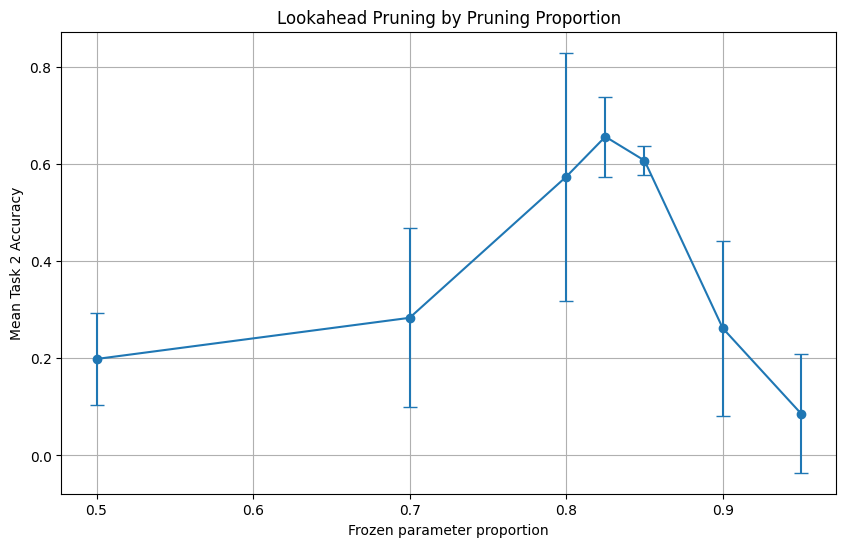

In [11]:
x = sorted(trial_results.keys())
trial_y = [np.mean(trial_results[key]) for key in x]
trial_yerr = [np.std(trial_results[key]) for key in x]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, trial_y, color="C0")
plt.errorbar(x, trial_y, yerr=trial_yerr, fmt='o', capsize=5, color='C0')
plt.xlabel("Frozen parameter proportion")
plt.ylabel("Mean Task 2 Accuracy")
plt.title("Lookahead Pruning by Pruning Proportion")
plt.grid(True)

plt.savefig("figures/fisher_lookahead_finding.pdf", dpi=300)

### Evaluate Best Pruning Prop

In [15]:
BEST_PRUNING_PROP = 0.825

baseline_results = defaultdict(list)
trial_results = defaultdict(list)

MAX_SEED = 15
for seed in range(5, MAX_SEED):
    model, failed = pretrain(seed=seed)
    if failed:
        continue
    # unregularised_model, failed = pretrain(seed=seed, use_regulariser=False)
    # if failed:
    #     continue
    baseline = run_baseline(model, seed=seed)
    # trial = run_trial(model=unregularised_model, prune_prop=BEST_PRUNING_PROP, lookahead=True, seed=seed)

    baseline_results[BEST_PRUNING_PROP].append(baseline)
    # trial_results[BEST_PRUNING_PROP].append(trial)

with open(f'fisher_performance_baseline_{MAX_SEED}.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)
# with open(f'fisher_performance_trial_{MAX_SEED}.json', 'w') as f:
#     json.dump(trial_results, f, indent=4)

Tasks: [[2, 3], [6, 7], [0, 1], [8, 9], [4, 5]]


Training Epochs: 100%|█| 5/5 [00:14<00:00,  2.96s/it, train_loss=


Test Results: [(0.0406, 0.9838), (9.0765, 0.0), (10.7057, 0.0), (9.5419, 0.0), (8.4328, 0.0)] (Avg: (7.5595, 0.1968))
Tasks: [[2, 3], [6, 7], [0, 1], [8, 9], [4, 5]]
Test Results: [(0.0406, 0.9838), (9.0765, 0.0), (10.7057, 0.0), (9.5419, 0.0), (8.4328, 0.0)] (Avg: (7.5595, 0.1968))
Dataset size: 2042
Initial acc constraint violation: -0.1957 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|█| 200/200 [00:10<00:00, 18.42it/s, size=1772.07, obj=0.285,


Final bbox:  Obj=0.29,  Size=1772.07,  Min acc hard=0.80,  Min acc soft=0.80
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 20 iterations for a total of 10 checkpoints
Checkpoints sizes: ['43.30', '204.54', '394.55', '597.67', '801.57', '999.80', '1199.60', '1394.16', '1588.17', '1772.07']
Checkpoint certificates: ['0.92', '0.89', '0.86', '0.82', '0.82', '0.80', '0.81', '0.81', '0.80', '0.80']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


...

Test Results: [(0.0278, 0.9915), (7.6558, 0.0), (6.8811, 0.0), (8.3096, 0.0), (8.124, 0.0)] (Avg: (6.1997, 0.1983))
Tasks: [[0, 9], [2, 5], [1, 6], [4, 7], [3, 8]]
Test Results: [(0.0278, 0.9915), (7.6558, 0.0), (6.8811, 0.0), (8.3096, 0.0), (8.124, 0.0)] (Avg: (6.1997, 0.1983))
Dataset size: 1989
Initial acc constraint violation: -0.1841 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.98,  Min acc soft=0.98


100%|█| 200/200 [00:12<00:00, 15.94it/s, size=2067.71, obj=0.333,


Final bbox:  Obj=0.33,  Size=2067.71,  Min acc hard=0.83,  Min acc soft=0.82
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 20 iterations for a total of 10 checkpoints
Checkpoints sizes: ['44.26', '241.24', '476.47', '710.76', '942.28', '1172.08', '1399.69', '1622.65', '1847.18', '2067.71']
Checkpoint certificates: ['0.93', '0.89', '0.89', '0.86', '0.84', '0.83', '0.83', '0.84', '0.83', '0.83']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|█| 5/5 [00:20<00:00,  4.11s/it, val_loss=1.


Test Results: [(0.3521, 0.9246), (1.1333, 0.4615), (7.7398, 0.0), (7.1994, 0.0), (9.3331, 0.0)] (Avg: (5.1515, 0.2772))


In [17]:
prev_perf = baseline_results[BEST_PRUNING_PROP]
new_perf = trial_results[BEST_PRUNING_PROP]

prev_acc = np.array(prev_perf).mean()
prev_std = np.array(prev_perf).std()
new_acc = np.array(new_perf).mean()
new_std = np.array(new_perf).std()

# 2. Create a prettier plot
# Use a more balanced figure size
fig, ax = plt.subplots(figsize=(7, 6))

# Define some nice colors
colors = ["C0", "C1"]  # Steel Blue and a nice Green

# Plot the bars with improved styling
bars = ax.bar(
    x=["Previous", "New"],
    height=[prev_acc, new_acc],
    yerr=[prev_std, new_std],
    color=colors,
    alpha=0.8,  # Make bars slightly transparent
    edgecolor="black",  # Add a crisp black edge
    capsize=10,  # THIS IS KEY: Adds caps to the error bars
    ecolor="black",  # Color of the error bar lines
    linewidth=1.5,
)

# 3. Add Labels, Title, and Grid for context
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Lookahead Pruning Performance", fontsize=16, pad=20)
ax.set_xticks(ticks=[0, 1], labels=["Baseline", "Lookahead Pruning"], fontsize=12)

# Add a subtle horizontal grid to make comparisons easier
ax.yaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.3)

# Remove the top and right spines for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Set a dynamic Y-axis limit for better spacing
ax.set_ylim(0, max(new_acc, prev_acc) + max(new_std, prev_std) + 0.05)

# 4. Add data labels on top of the bars
# This shows the exact mean value on the plot
ax.bar_label(bars, fmt="{:.3f}", padding=5, fontsize=11, color="black")

# Ensure everything fits without overlapping
plt.tight_layout()

plt.savefig("figures/fisher_performance.pdf", dpi=300)
plt.show()

## Non Lookahead Pruning

### Find Best Pruning Prop

In [ ]:
trial_results = defaultdict(list)

for seed in range(1, 15):
    unregularised_model, failed= pretrain(seed=seed, use_regulariser=False)
    if failed:
        continue
    for prune_prop in [0.5, 0.7, 0.8, 0.825, 0.85, 0.9, 0.95]:
        trial = run_trial(model=unregularised_model, prune_prop=prune_prop, lookahead=False, seed=seed)

        trial_results[prune_prop].append(trial)

    with open(f'fisher_finding_{seed}.json', 'w') as f:
        json.dump(trial_results, f, indent=4)

Tasks: [[0, 7], [5, 8], [4, 9], [3, 6], [1, 2]]


Training Epochs: 100%|█| 5/5 [00:11<00:00,  2.25s/it, train_lo


Test Results: [(0.0265, 0.993), (31.4595, 0.0), (30.7783, 0.0), (32.5791, 0.0), (26.0361, 0.0)] (Avg: (24.1759, 0.1986))
Tasks: [[0, 7], [5, 8], [4, 9], [3, 6], [1, 2]]
Test Results: [(0.0265, 0.993), (31.4595, 0.0), (30.7783, 0.0), (32.5791, 0.0), (26.0361, 0.0)] (Avg: (24.1759, 0.1986))
Found global SI threshold: 0.00000000
Freezing MOST important 3089 out of 6179 parameters.
Dataset size: 2008
Initial acc constraint violation: -0.1927 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.99,  Min acc soft=0.99


100%|█| 300/300 [00:16<00:00, 17.84it/s, size=1640.46, obj=0.2


Final bbox:  Obj=0.27,  Size=1640.46,  Min acc hard=0.83,  Min acc soft=0.83
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 3 checkpoints
Checkpoints sizes: ['602.33', '1137.43', '1640.46']
Checkpoint certificates: ['0.90', '0.90', '0.83']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


...

100%|█| 300/300 [00:16<00:00, 17.98it/s, size=1834.43, obj=0.2


Final bbox:  Obj=0.30,  Size=1834.43,  Min acc hard=0.79,  Min acc soft=0.79
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 3 checkpoints
Checkpoints sizes: ['656.86', '1262.66', '1834.43']
Checkpoint certificates: ['0.83', '0.80', '0.79']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|█| 5/5 [00:13<00:00,  2.79s/it, val_loss


Test Results: [(0.3996, 0.8713), (5.0988, 0.0671), (30.0786, 0.0), (30.2169, 0.0), (31.8088, 0.0)] (Avg: (19.5205, 0.1877))
Tasks: [[0, 5], [2, 3], [4, 7], [1, 8], [6, 9]]
Test Results: [(0.022, 0.9915), (32.7824, 0.0), (29.0055, 0.0), (29.8522, 0.0), (31.14, 0.0)] (Avg: (24.5604, 0.1983))
Found global SI threshold: 0.00000000
Freezing MOST important 1854 out of 6179 parameters.
Dataset size: 1872
Initial acc constraint violation: -0.1960 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


 10%| | 30/300 [00:01<00:15, 16.97it/s, size=115.13, obj=0.017

### Evaluate Best Pruning Prop